**Task 4: Predicting Insurance Claim Amounts**

**Objective:**

In this project, we aim to predict medical insurance costs (charges) using personal attributes. Since the target variable (charges) is continuous, we use Linear Regression. This analysis helps in understanding how lifestyle and demographic factors influence healthcare expenses.

**Data Loading**

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the Medical Cost Personal Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Pre-processing**

In [15]:
# 1. Handle Missing Values (Forward Fill)
df.ffill(inplace=True)

# 2. Convert Categorical variables (sex, smoker, region) into numbers
# This is called One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("Missing values check:")
print(df.isnull().sum())
print("\nData transformed for modeling.")

Missing values check:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data transformed for modeling.


**Feature Correlation & Visualization**

1. Visualization Smoking Impact:

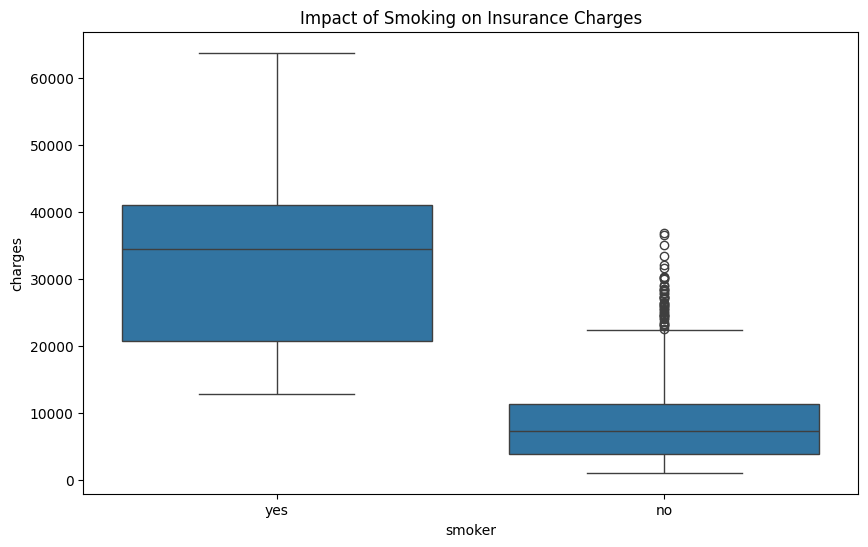

In [16]:
# 1. Visualization: Impact of Smoking on Charges
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Impact of Smoking on Insurance Charges")
plt.show()

2. Visualization Age and BMI Impact

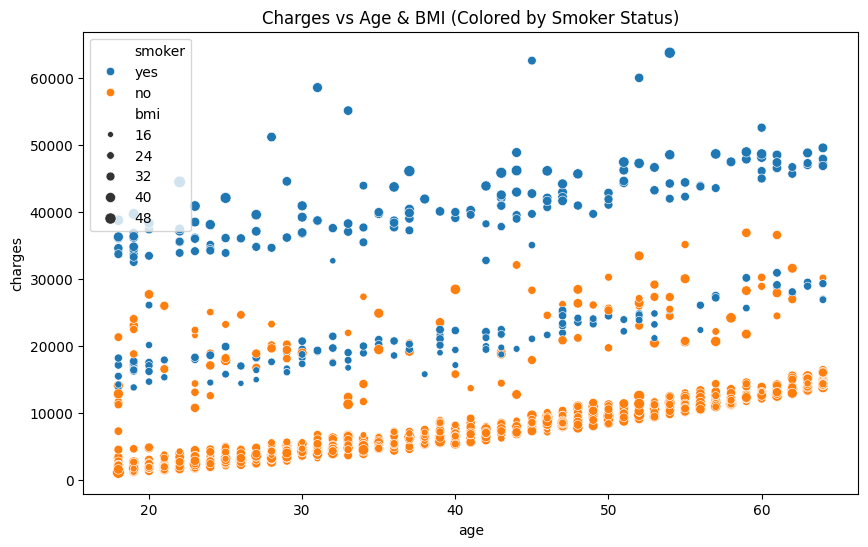

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', size='bmi', data=df)
plt.title("Charges vs Age & BMI (Colored by Smoker Status)")
plt.show()

**Regression Modeling**

Here we split the data and train the Linear Regression model

In [18]:
# Define Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Training Complete!")

Linear Regression Model Training Complete!


**Error Evaluation**

We must evaluate the model using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

In [21]:
# Generate predictions on test data to evaluate model performance
y_pred = model.predict(X_test)

# Calculate Errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


 **Insights & Conclusion**

1. Smoker status is the most significant factor; smokers incur much higher charges regardless of age.

2. Age shows a steady increase in costs as applicants get older.

3. Model Performance: The model predicts charges with an MAE of [insert your MAE value], which is a good baseline for regression modeling.